# Hybrid Review: Jev + LLM

In this notebook, we will combine a decision model (**Jev**) with an LLM reviewer. Jev screens every article in a
fraction of a second for a fraction of a cent. The LLM, which is slower and more expensive but can reason through
harder cases, only sees the articles Jev is unsure about, and then extracts details from the included ones.

We measure recall, precision, cost, and wall time on a labeled sample, and compare two pipelines:

- **Pipeline A (confidence-gated):** Jev screens all articles; uncertain ones go to the LLM; included ones go to an
  LLM `AbstractionReviewer`.
- **Pipeline B (parallel):** Jev and the LLM review every article side by side, and we analyze where they agree.

## Setting up the notebook

High-level configs

In [1]:
from dotenv import load_dotenv

# Load environment variables from .env file. Adjust the path to the .env file as needed.
load_dotenv(dotenv_path="../../.env")

# Enable asyncio in Jupyter
import asyncio
import nest_asyncio

nest_asyncio.apply()

# Add the package to the path (required if you are running this notebook from the tutorials folder)
import sys

sys.path.append("../../")

Import required packages

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lattereview.providers import SystemOneProvider, OpenAIProvider
from lattereview.agents import DecisionTitleAbstractReviewer, TitleAbstractReviewer, AbstractionReviewer
from lattereview.workflows import ReviewWorkflow

pd.set_option("display.max_colwidth", 100)

## Data

A stratified sample of 160 articles from the custom evaluation dataset (`evaluation/custom_data`), with the
ground-truth `label` of "search 2": CT-based deep learning classifiers, excluding PET and cardiovascular studies.

In [3]:
data = pd.read_csv("data.csv")
print(f"{len(data)} articles, {data['label'].sum()} included")
data.head()

160 articles, 60 included


,title,abstract,modality,task,deep_learning,cardiovascular,label
0,Semantic segmentation and detection of mediastinal lymph nodes and anatomical structures in CT d...,PURPOSE: Accurate lung cancer diagnosis is crucial to select the best course of action for treat...,ct,segmentation,1,0,0
1,DenseCapsNet: Detection of COVID-19 from X-ray images using a capsule neural network,"At present, the global pandemic as it relates to novel coronavirus pneumonia is still a very dif...",xr,classification,1,0,0
2,Deep learning representations to support COVID-19 diagnosis on CT slices,INTRODUCTION: The coronavirus disease 2019 (COVID-19) has become a significant public health pro...,ct,classification,1,0,1
3,Three-Terminal Ovonic Threshold Switch (3T-OTS) with Tunable Threshold Voltage for Versatile Art...,"Inspired by information processing in biological systems, sensor-combined edge-computing systems...",xr,classification,1,0,0
4,Deep segmentation networks predict survival of non-small cell lung cancer,Non-small-cell lung cancer (NSCLC) represents approximately 80-85% of lung cancer diagnoses and ...,pet,survival,1,0,0


In [4]:
inclusion_criteria = {
    1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
    2: "The study should introduce, develop, or discuss a deep learning-based classifier.",
}
exclusion_criteria = {
    1: "The study must not include PET scans as one of its modalities.",
    2: "Studies focusing on cardiovascular organs or lung vasculature must be excluded.",
}

# The LLM reviewer takes the criteria as text.
inclusion_text = "\n".join(f"{k}. {v}" for k, v in inclusion_criteria.items())
exclusion_text = "\n".join(f"{k}. {v}" for k, v in exclusion_criteria.items())

## Reviewers

In [5]:
def make_reviewers():
    jev = DecisionTitleAbstractReviewer(
        provider=SystemOneProvider(backend="typesafe"),
        name="Jev",
        inclusion_criteria=inclusion_criteria,
        exclusion_criteria=exclusion_criteria,
        verbose=False,
    )
    llm = TitleAbstractReviewer(
        provider=OpenAIProvider(model="gpt-6-luna"),
        name="LLM",
        backstory="a PhD researcher in radiology and deep learning",
        inclusion_criteria=inclusion_text,
        exclusion_criteria=exclusion_text,
        verbose=False,
    )
    extractor = AbstractionReviewer(
        provider=OpenAIProvider(model="gpt-6-luna"),
        name="Extractor",
        abstraction_keys={"task": str, "organ": str, "dataset_size": str},
        key_descriptions={
            "task": "The model's task, e.g., classification, detection, or segmentation.",
            "organ": "The main organ or body region studied.",
            "dataset_size": "The number of patients or images used, as reported in the abstract, or 'not reported'.",
        },
        verbose=False,
    )
    return jev, llm, extractor


def recall_precision(labels, predicted):
    labels, predicted = np.asarray(labels).astype(bool), np.asarray(predicted).astype(bool)
    tp = (labels & predicted).sum()
    return tp / labels.sum(), tp / predicted.sum() if predicted.sum() else float("nan")

## Pipeline A: Jev first, LLM for uncertain articles

Round A: Jev screens everything. Round B: articles whose `include_probability` falls in the uncertain band go to
the LLM. Articles outside the band keep Jev's decision (`include_probability >= 0.5`); routed articles are included
when the LLM's evaluation is at least 3. Round C: the LLM extracts details from every included article.

The band was chosen from the full-scale evaluation in `evaluation/decision_evaluation.ipynb`: Jev's probabilities
are mostly close to 0 or 1, so a band of [0.1, 0.9) routes only the genuinely uncertain articles.

In [6]:
LOW, HIGH = (0.1, 0.9)


def is_uncertain(row):
    return LOW <= row["round-A_Jev_include_probability"] < HIGH


def is_included(row):
    if is_uncertain(row):
        return row["round-B_LLM_evaluation"] >= 3
    return row["round-A_Jev_include_probability"] >= 0.5


jev, llm, extractor = make_reviewers()
pipeline_a = ReviewWorkflow(
    workflow_schema=[
        {"round": "A", "reviewers": [jev], "text_inputs": ["title", "abstract"]},
        {"round": "B", "reviewers": [llm], "text_inputs": ["title", "abstract"], "filter": is_uncertain},
        {"round": "C", "reviewers": [extractor], "text_inputs": ["title", "abstract"], "filter": is_included},
    ],
    verbose=False,
)

start = time.time()
result_a = asyncio.run(pipeline_a(data))
seconds_a = time.time() - start
if "round-B_LLM_evaluation" not in result_a.columns:  # no article was uncertain
    result_a["round-B_LLM_evaluation"] = None
result_a["included"] = result_a.apply(is_included, axis=1)

print(f"Wall time: {seconds_a:.1f} s")
print(f"Articles sent to the LLM for screening: {result_a.apply(is_uncertain, axis=1).sum()} of {len(result_a)}")
for (round_id, name), cost in pipeline_a.reviewer_costs.items():
    print(f"Round {round_id} ({name}): ${cost:.5f}")

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:15:   0%|          | 0/160 [00:00<?, ?it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:15:   1%|▏         | 2/160 [00:00<00:26,  6.00it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:15:   3%|▎         | 5/160 [00:00<00:13, 11.12it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:15:   5%|▌         | 8/160 [00:00<00:11, 12.96it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:15:   8%|▊         | 12/160 [00:00<00:08, 17.48it/s]

...

['round: C', 'reviewer_name: Extractor'] -                     2026-09-27 17:40:32:  92%|█████████▏| 66/72 [00:05<00:00, 13.43it/s]

['round: C', 'reviewer_name: Extractor'] -                     2026-09-27 17:40:32:  96%|█████████▌| 69/72 [00:05<00:00, 15.14it/s]

['round: C', 'reviewer_name: Extractor'] -                     2026-09-27 17:40:32: 100%|██████████| 72/72 [00:06<00:00, 15.25it/s]

['round: C', 'reviewer_name: Extractor'] -                     2026-09-27 17:40:32: 100%|██████████| 72/72 [00:06<00:00, 11.52it/s]

Wall time: 22.6 s
Articles sent to the LLM for screening: 28 of 160
Round A (Jev): $0.00893
Round B (LLM): $0.00476
Round C (Extractor): $0.00772


The uncertain articles, with Jev's per-criterion probabilities and the LLM's decision:

In [7]:
uncertain = result_a[result_a.apply(is_uncertain, axis=1)]
for _, row in uncertain.iterrows():
    print(f"Title: {row['title']}")
    print(f"Label: {row['label']}")
    print(f"Jev: {row['round-A_Jev_reasoning']}")
    print(f"LLM ({row['round-B_LLM_evaluation']}): {row['round-B_LLM_reasoning']}")
    print("-" * 100)

Title: RCoNet: Deformable Mutual Information Maximization and High-Order Uncertainty-Aware Learning for Robust COVID-19 Detection
Label: 0
Jev: P(include)=0.24; rated 'better to exclude'. Likely fails inclusion 1 (p=0.37: 'The study must involve CT scans. If multiple modalities are…'). No exclusion criterion likely applies (highest p=0.10).
LLM (1): The study develops a deep-learning classifier but uses only chest X-ray images, not CT scans, so it fails a required inclusion criterion.
----------------------------------------------------------------------------------------------------
Title: Detection Methods of COVID-19
Label: 0
Jev: P(include)=0.38; rated 'not sure whether to include or exclude'. Likely fails inclusion 2 (p=0.48: 'The study should introduce, develop, or discuss a deep lear…'). No exclusion criterion likely applies (highest p=0.18).
LLM (2): Although CT imaging is mentioned, the abstract does not state that the proposed method uses deep learning or develops a classifie

Details extracted from the included articles:

In [8]:
result_a.loc[result_a["included"], ["title", "label", "round-C_Extractor_task", "round-C_Extractor_organ", "round-C_Extractor_dataset_size"]].head(10)

,title,label,round-C_Extractor_task,round-C_Extractor_organ,round-C_Extractor_dataset_size
0,Semantic segmentation and detection of mediastinal lymph nodes and anatomical structures in CT d...,0,Semantic segmentation and instance detection,Mediastinum,15 patients
2,Deep learning representations to support COVID-19 diagnosis on CT slices,1,Classification of COVID-19 versus control cases,Lungs (thorax),not reported
6,Diagnostic Value of Deep Learning-Based CT Feature for Severe Pulmonary Infection,0,CT image segmentation for diagnosis of severe pulmonary infection,Lungs,100 patients
10,Wavelet decomposition facilitates training on small datasets for medical image classification by...,1,Classification of suspicious lung nodules as malignant or benign,Lung,not reported
12,Recognition of COVID-19 from CT Scans Using Two-Stage Deep-Learning-Based Approach: CNR-IEMN,1,"Classification of volumetric CT scans into normal, COVID-19, or community-acquired pneumonia cla...",Lungs,not reported
16,AIR-Net: A novel multi-task learning method with auxiliary image reconstruction for predicting E...,1,Classification of EGFR mutation status,Lung,not reported
17,A hybrid CNN feature model for pulmonary nodule malignancy risk differentiation,1,Classification of pulmonary nodule malignancy risk,Lung,not reported
19,Automated Pulmonary Nodule Classification in Computed Tomography Images Using a Deep Convolution...,1,Classification of pulmonary nodules as benign or malignant,Lung,60 cases
22,Towards automatic pulmonary nodule management in lung cancer screening with deep learning,1,Classification of pulmonary nodule types,Lung,not reported
23,3D multi-view convolutional neural networks for lung nodule classification,1,Lung nodule classification,Lung,not reported


## Pipeline B: Jev and the LLM in parallel

Both reviewers see every article in the same round. This costs the full LLM price, but shows where the two kinds
of reviewers agree and disagree.

In [9]:
jev_b, llm_b, _ = make_reviewers()
pipeline_b = ReviewWorkflow(
    workflow_schema=[{"round": "A", "reviewers": [jev_b, llm_b], "text_inputs": ["title", "abstract"]}],
    verbose=False,
)

start = time.time()
result_b = asyncio.run(pipeline_b(data))
seconds_b = time.time() - start
jev_include = result_b["round-A_Jev_include_probability"] >= 0.5
llm_include = result_b["round-A_LLM_evaluation"] >= 3

print(f"Wall time: {seconds_b:.1f} s (both reviewers run one after the other within the round)")
print(f"Jev cost: ${pipeline_b.reviewer_costs[('A', 'Jev')]:.5f}, LLM cost: ${pipeline_b.reviewer_costs[('A', 'LLM')]:.5f}")
pd.crosstab(jev_include.rename("Jev includes"), llm_include.rename("LLM includes"))

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:38:   0%|          | 0/160 [00:00<?, ?it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:38:   1%|▏         | 2/160 [00:00<00:21,  7.20it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:38:   2%|▎         | 4/160 [00:00<00:16,  9.21it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:38:   4%|▍         | 7/160 [00:00<00:10, 14.40it/s]

['round: A', 'reviewer_name: Jev'] -                     2026-09-27 17:40:38:   6%|▌         | 9/160 [00:00<00:09, 15.50it/s]

...

['round: A', 'reviewer_name: LLM'] -                     2026-09-27 17:40:48:  99%|█████████▉| 158/160 [00:13<00:00,  9.44it/s]

['round: A', 'reviewer_name: LLM'] -                     2026-09-27 17:40:48: 100%|██████████| 160/160 [00:14<00:00,  8.96it/s]

['round: A', 'reviewer_name: LLM'] -                     2026-09-27 17:40:48: 100%|██████████| 160/160 [00:14<00:00, 11.18it/s]

Wall time: 24.1 s (both reviewers run one after the other within the round)
Jev cost: $0.00893, LLM cost: $0.02152


LLM includes,False,True
Jev includes,,
False,82,1
True,9,68


Agreement by ground truth: which reviewer is right when they disagree?

In [10]:
disagree = jev_include != llm_include
print(f"Disagreements: {disagree.sum()} of {len(result_b)} articles")
print(f"  Jev right: {(jev_include[disagree] == result_b['label'][disagree].astype(bool)).sum()}")
print(f"  LLM right: {(llm_include[disagree] == result_b['label'][disagree].astype(bool)).sum()}")

Disagreements: 10 of 160 articles
  Jev right: 2
  LLM right: 8


In [11]:
for _, row in result_b[disagree].head(5).iterrows():
    print(f"Title: {row['title']}")
    print(f"Label: {row['label']}")
    print(f"Jev: {row['round-A_Jev_reasoning']}")
    print(f"LLM ({row['round-A_LLM_evaluation']}): {row['round-A_LLM_reasoning']}")
    print("-" * 100)

Title: Diagnostic Value of Deep Learning-Based CT Feature for Severe Pulmonary Infection
Label: 0
Jev: P(include)=0.95; rated 'absolutely include'. Likely meets all inclusion criteria (lowest p=0.83). No exclusion criterion likely applies (highest p=0.07).
LLM (2): Although the study uses CT and proposes a deep-learning U-Net method, its primary method is image segmentation rather than a deep-learning-based classifier, so it does not clearly meet the classifier inclusion criterion.
----------------------------------------------------------------------------------------------------
Title: Clinical evaluation of atlas and deep learning based automatic contouring for lung cancer
Label: 0
Jev: P(include)=0.58; rated 'better to include'. Likely fails inclusion 2 (p=0.34: 'The study should introduce, develop, or discuss a deep lear…'). No exclusion criterion likely applies (highest p=0.33).
LLM (2): The study uses CT scans and deep learning for organ contouring, but it does not discuss a dee

## Results

In [12]:
jev_cost = pipeline_b.reviewer_costs[("A", "Jev")]
llm_cost = pipeline_b.reviewer_costs[("A", "LLM")]
screening_cost_a = sum(cost for (round_id, _), cost in pipeline_a.reviewer_costs.items() if round_id in ("A", "B"))
routed = int(result_a.apply(is_uncertain, axis=1).sum())

rows = []
for name, predicted, sent_to_llm, cost in [
    ("Jev only", jev_include, 0, jev_cost),
    ("LLM only", llm_include, len(data), llm_cost),
    ("Pipeline A: Jev + LLM for uncertain", result_a["included"], routed, screening_cost_a),
    ("Pipeline B: include if either includes", jev_include | llm_include, len(data), jev_cost + llm_cost),
    ("Pipeline B: include if both include", jev_include & llm_include, len(data), jev_cost + llm_cost),
]:
    recall, precision = recall_precision(data["label"], predicted)
    rows.append(
        {"pipeline": name, "sent to LLM": sent_to_llm, "recall": recall, "precision": precision, "screening cost ($)": cost}
    )
results = pd.DataFrame(rows).set_index("pipeline")
results.round(4)

,sent to LLM,recall,precision,screening cost ($)
pipeline,,,,
Jev only,0,0.8833,0.6883,0.0089
LLM only,160,0.8667,0.7536,0.0215
Pipeline A: Jev + LLM for uncertain,28,0.8833,0.7361,0.0137
Pipeline B: include if either includes,160,0.9000,0.6923,0.0305
Pipeline B: include if both include,160,0.8500,0.7500,0.0305


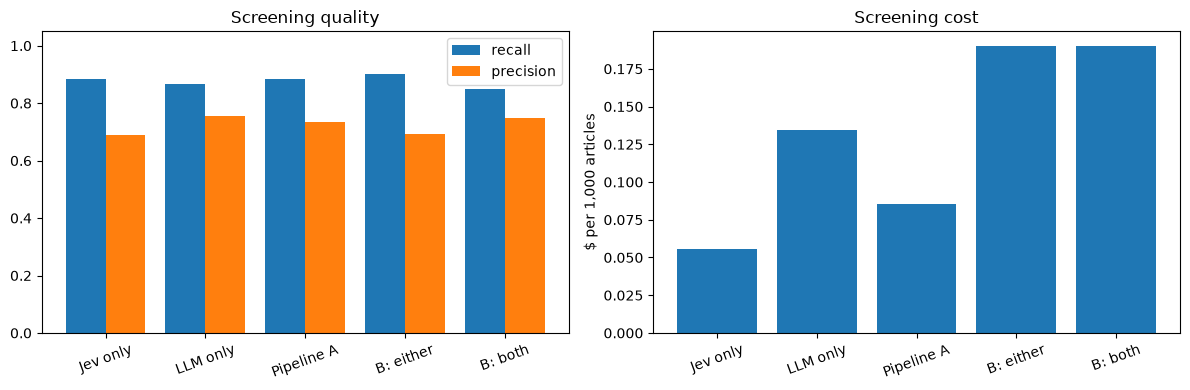

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["Jev only", "LLM only", "Pipeline A", "B: either", "B: both"]
x = np.arange(len(labels))
axes[0].bar(x - 0.2, results["recall"], width=0.4, label="recall")
axes[0].bar(x + 0.2, results["precision"], width=0.4, label="precision")
axes[0].set_xticks(x, labels, rotation=20)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_title("Screening quality")
axes[1].bar(x, results["screening cost ($)"] * 1000 / len(data))
axes[1].set_xticks(x, labels, rotation=20)
axes[1].set_ylabel("$ per 1,000 articles")
axes[1].set_title("Screening cost")
plt.tight_layout()
plt.show()

Takeaways from this sample:

- **Pipeline A** sent 28 of 160 articles (18%) to the LLM. It kept Jev's recall (0.88) and reached nearly the LLM's precision (0.74 vs 0.75), for about 64% of the LLM-only screening cost.
- **Jev alone** had about the same recall as the LLM (0.88 vs 0.87) but lower precision (0.69 vs 0.75).
- **When the two disagreed, the LLM was right in 8 of 10 cases**, mostly segmentation studies that Jev counted as classifiers. Telling these apart takes an extra reasoning step, which Jev does not do, so this is where an LLM earns its cost.
- **Cost:** Jev cost about $0.06 per 1,000 articles here and `gpt-6-luna` about $0.13. Against a cheap LLM, Jev saves about half; against larger models (e.g., `gpt-6-sol`), the saving is one to two orders of magnitude. Jev's other advantages are speed and a probability you can threshold.

The sample is small, so treat these numbers as an illustration. See `evaluation/decision_evaluation.ipynb` for the
full-scale results on 12,815 articles.